In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

In [3]:
data_path = "S05-hw-dataset.csv"
df = pd.read_csv(data_path)

df.head()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [5]:
df.describe()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [6]:
df["default"].value_counts(normalize=True)


default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

In [7]:
X = df.drop(columns=["default", "client_id"])
y = df["default"]

print(X.shape, y.shape)


(3000, 15) (3000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(default
 0    0.589778
 1    0.410222
 Name: proportion, dtype: float64,
 default
 0    0.589333
 1    0.410667
 Name: proportion, dtype: float64)

In [9]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print("Baseline accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline ROC-AUC :", roc_auc_score(y_test, y_proba_base))


Baseline accuracy: 0.5893333333333334
Baseline ROC-AUC : 0.5


In [10]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipe


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [11]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0],
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_


({'logreg__C': 1.0}, np.float64(0.8631695636003741))

In [12]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)


Accuracy : 0.7933333333333333
ROC-AUC  : 0.8647088205911735
Precision: 0.7802197802197802
Recall   : 0.6915584415584416
F1-score : 0.7332185886402753


array([[382,  60],
       [ 95, 213]])

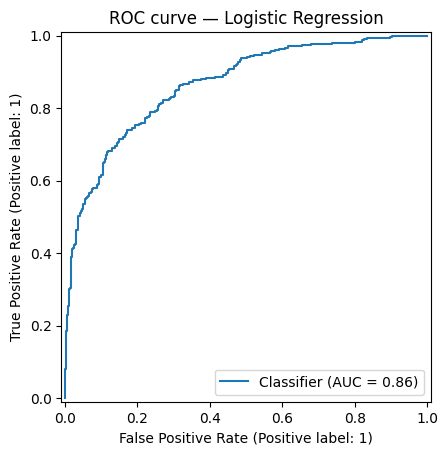

In [17]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC curve — Logistic Regression")
plt.savefig("figures/roc_curve.png", dpi=150)
plt.show()

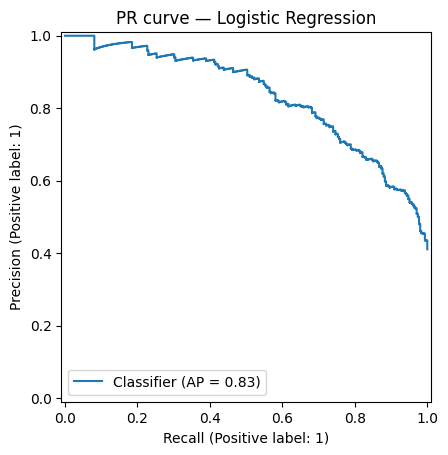

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("PR curve — Logistic Regression")
plt.savefig("figures/pr_curve.png", dpi=150)
plt.show()


Для оценки качества моделей был проведён честный ML-эксперимент с train/test-сплитом и фиксированным random_state.

Бейзлайн-модель DummyClassifier показала accuracy = 0.59 и ROC-AUC = 0.50, что соответствует отсутствию предсказательной способности.

Логистическая регрессия в виде Pipeline со стандартизацией признаков и подбором параметра регуляризации показала существенно лучшее качество: ROC-AUC = 0.86, accuracy = 0.79, precision = 0.78, recall = 0.69, F1-score = 0.73.

Модель значительно превосходит бейзлайн по всем ключевым метрикам и демонстрирует хорошее качество ранжирования клиентов по риску дефолта, поэтому может рассматриваться как разумная базовая модель для данной задачи.